In [128]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, random_split, TensorDataset
import torch.nn.functional as torch_F # avoid import problems becasue F is used as a variable

import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import json

import sys
sys.path.append('../src')

from preprocessing import *
from models import  *
from utils import *

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [129]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 20,              # Base font size
    'axes.titlesize': 20,         # Title font size
    'axes.labelsize': 20,         # Axes label font size
    'xtick.labelsize': 20,        # X-tick label font size
    'ytick.labelsize': 20,        # Y-tick label font size
    'legend.fontsize': 20,        # Legend font size
    'figure.titlesize': 20,       # Figure title size
    'figure.dpi': 300,            # Figure DPI for high resolution
    'savefig.dpi': 300            # Save figure DPI
})

# Make lines thicker
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5

# Increase marker size default
plt.rcParams['lines.markersize'] = 8

In [130]:
# Loading
df = pd.read_csv('../data/study_results/responses.csv')

with open('../data/results/shap.json', 'r') as file:
    shap_json = json.load(file)

In [131]:
# Define metadata columns that we'll exclude from feature analysis
metadata_columns = [
    "#", "Datenschutzerklärung",
    "Bitte geben Sie Ihre aktuelle Berufsbezeichnung sowie Ihren Fachbereich an:",
    "Wie viele Jahre Berufserfahrung haben Sie in Ihrem aktuellen Fachbereich?",
    "Response Type", "Start Date (UTC)", "Stage Date (UTC)", "Submit Date (UTC)",
    "Network ID", "Tags"
]

# Define the translation dictionary for feature names
german_to_english = {
    "Alter des Empfängers": "Age",
    "Geschlecht des Empfängers": "gender",
    "Grunderkrankung, die zur Nierenschädigung geführt hat": "underlying_disease",
    "Blutgruppe des Empfängers": "blood_group",
    "Kalte Ischämiezeit": "cold_ischemia_time",
    "Geschlecht des Spenders": "gender_donor",
    "Alter des Spenders": "age_donor",
    "Blutgruppe des Spenders": "donor_bloodgroup",
    "Art der Spende (Lebendspende oder postmortale Spende)": "type_of_donation",
    "PIRCHE-Score": "pirche_score",
    "Broad Antigen Mismatch (HLA-Inkompatibilität)": "mm_broad",
    "Herzfrequenz": "Heart rate",
    "Blutdruck": "Blood pressure",
    "Gewicht": "weight",
    "Temperatur": "Temperature",
    "Urinvolumen": "urine_volume",
    "Serumkreatinin": "Creatinine",
    "Leukozyten im Blut": "Leukocyte",
    "C-reaktives Protein": "C-reactive protein",
    "Proteinurie": "Proteinuria",
    "Albumin/Kreatinin-Verhältnis": "acr",
    "eGFR": "eGFR",
    "Tacrolimus Dosis": "Tacrolimus",
    "Methylprednisolon Dosis": "Methylprednisolon",
    "Ciclosporin Dosis": "Ciclosporin",
    "Anzahl der Dialysesitzungen": "number_dialyses"
}

# Define the translation for the Likert scale
likert_translation = {
    "Sehr relevant": 1,
    "Relevant": 2,
    "Neutral": 3,
    "Weniger relevant": 4,
    "Am wenigsten relevant": 5
}

# Get all feature columns (excluding metadata)
feature_columns = [col for col in df.columns if col not in metadata_columns]

# Calculate the number of features per task (should be equal for all 3 tasks)
features_per_task = len(feature_columns) // 3

# Split the columns into the three tasks
graft_loss_columns = feature_columns[:features_per_task]
rejection_columns = feature_columns[features_per_task:2*features_per_task]
mortality_columns = feature_columns[2*features_per_task:3*features_per_task]

# Function to extract the base feature name and translate it
def extract_feature_name(column_name):
    for german_name in german_to_english.keys():
        if german_name in column_name:
            return german_to_english[german_name]
    return column_name  # Return original if no translation found

# Process each task to extract features and ratings
def process_task_data(task_columns, df):
    task_data = {}

    for column in task_columns:
        # Extract the base feature name and translate it
        feature_name = extract_feature_name(column)

        # Map the Likert scale value to a numeric score
        likert_values = df[column].map(likert_translation).values

        # Store the feature and its rating
        task_data[feature_name] = likert_values[0]  # Using [0] as we only have one participant

    return task_data

# Process data for each task
graft_loss_data = process_task_data(graft_loss_columns, df)
rejection_data = process_task_data(rejection_columns, df)
mortality_data = process_task_data(mortality_columns, df)

# Store the data in a format suitable for plotting
task_data = {
    "Graft Loss": graft_loss_data,
    "Rejection": rejection_data,
    "Mortality": mortality_data
}

shap_data = {
    "Graft Loss": {item["feature"]: item["importance"] for item in shap_json["prediction_tasks"]["graft_loss"]},
    "Rejection": {item["feature"]: item["importance"] for item in shap_json["prediction_tasks"]["graft_rejection"]},
    "Mortality": {item["feature"]: item["importance"] for item in shap_json["prediction_tasks"]["mortality"]}
}

In [132]:
task_data

{'Graft Loss': {'Age': 2,
  'gender': 3,
  'underlying_disease': 2,
  'blood_group': 5,
  'cold_ischemia_time': 2,
  'gender_donor': 3,
  'age_donor': 1,
  'donor_bloodgroup': 5,
  'type_of_donation': 1,
  'pirche_score': 1,
  'mm_broad': 2,
  'Heart rate': 5,
  'Blood pressure': 2,
  'weight': 5,
  'Temperature': 5,
  'urine_volume': 5,
  'Creatinine': 1,
  'Leukocyte': 5,
  'C-reactive protein': 5,
  'Proteinuria': 1,
  'acr': 1,
  'eGFR': 1,
  'Tacrolimus': 2,
  'Methylprednisolon': 4,
  'Ciclosporin': 2,
  'number_dialyses': 2},
 'Rejection': {'Age': 4,
  'gender': 5,
  'underlying_disease': 4,
  'blood_group': 4,
  'cold_ischemia_time': 1,
  'gender_donor': 5,
  'age_donor': 2,
  'donor_bloodgroup': 5,
  'type_of_donation': 2,
  'pirche_score': 1,
  'mm_broad': 1,
  'Heart rate': 5,
  'Blood pressure': 4,
  'weight': 5,
  'Temperature': 5,
  'urine_volume': 4,
  'Creatinine': 1,
  'Leukocyte': 5,
  'C-reactive protein': 4,
  'Proteinuria': 2,
  'acr': 2,
  'eGFR': 1,
  'Tacrolimus

In [133]:
shap_data

{'Graft Loss': {'Creatinine': 0.129,
  'eGFR': 0.083,
  'Tacrolimus': 0.046,
  'Proteinuria': 0.045,
  'Ciclosporin': 0.042,
  'ACR': 0.038,
  'Leukocyte': 0.032,
  'Blood pressure': 0.027,
  'crphp': 0.026,
  'urine_volume': 0.015,
  'bp_sys': 0.024,
  'Methylprednisolon': 0.013,
  'temperature': 0.006,
  'diuresis_time': 0.018,
  'hr': 0.017,
  'weight': 0.008,
  'mm_broad': 0.012,
  'type_of_donation': 0.012,
  'number_dialyses': 0.014,
  'gender': 0.008,
  'Notes embeddings': 0.048,
  'donor_bloodgroup': 0.006,
  'blood_group': 0.005,
  'pirche_score': 0.017,
  'underlying_disease': 0.032,
  'Age': 0.03,
  'age_donor': 0.023,
  'cold_ischemia_time': 0.013,
  'gender_donor': 0.003},
 'Rejection': {'Creatinine': 0.122,
  'Leukocyte': 0.081,
  'Tacrolimus': 0.071,
  'Ciclosporin': 0.065,
  'eGFR': 0.088,
  'C-reactive protein': 0.042,
  'Methylprednisolon': 0.042,
  'Proteinuria': 0.036,
  'Heart rate': 0.027,
  'mm_broad': 0.024,
  'bp_dia': 0.023,
  'bp_sys': 0.021,
  'temperature':

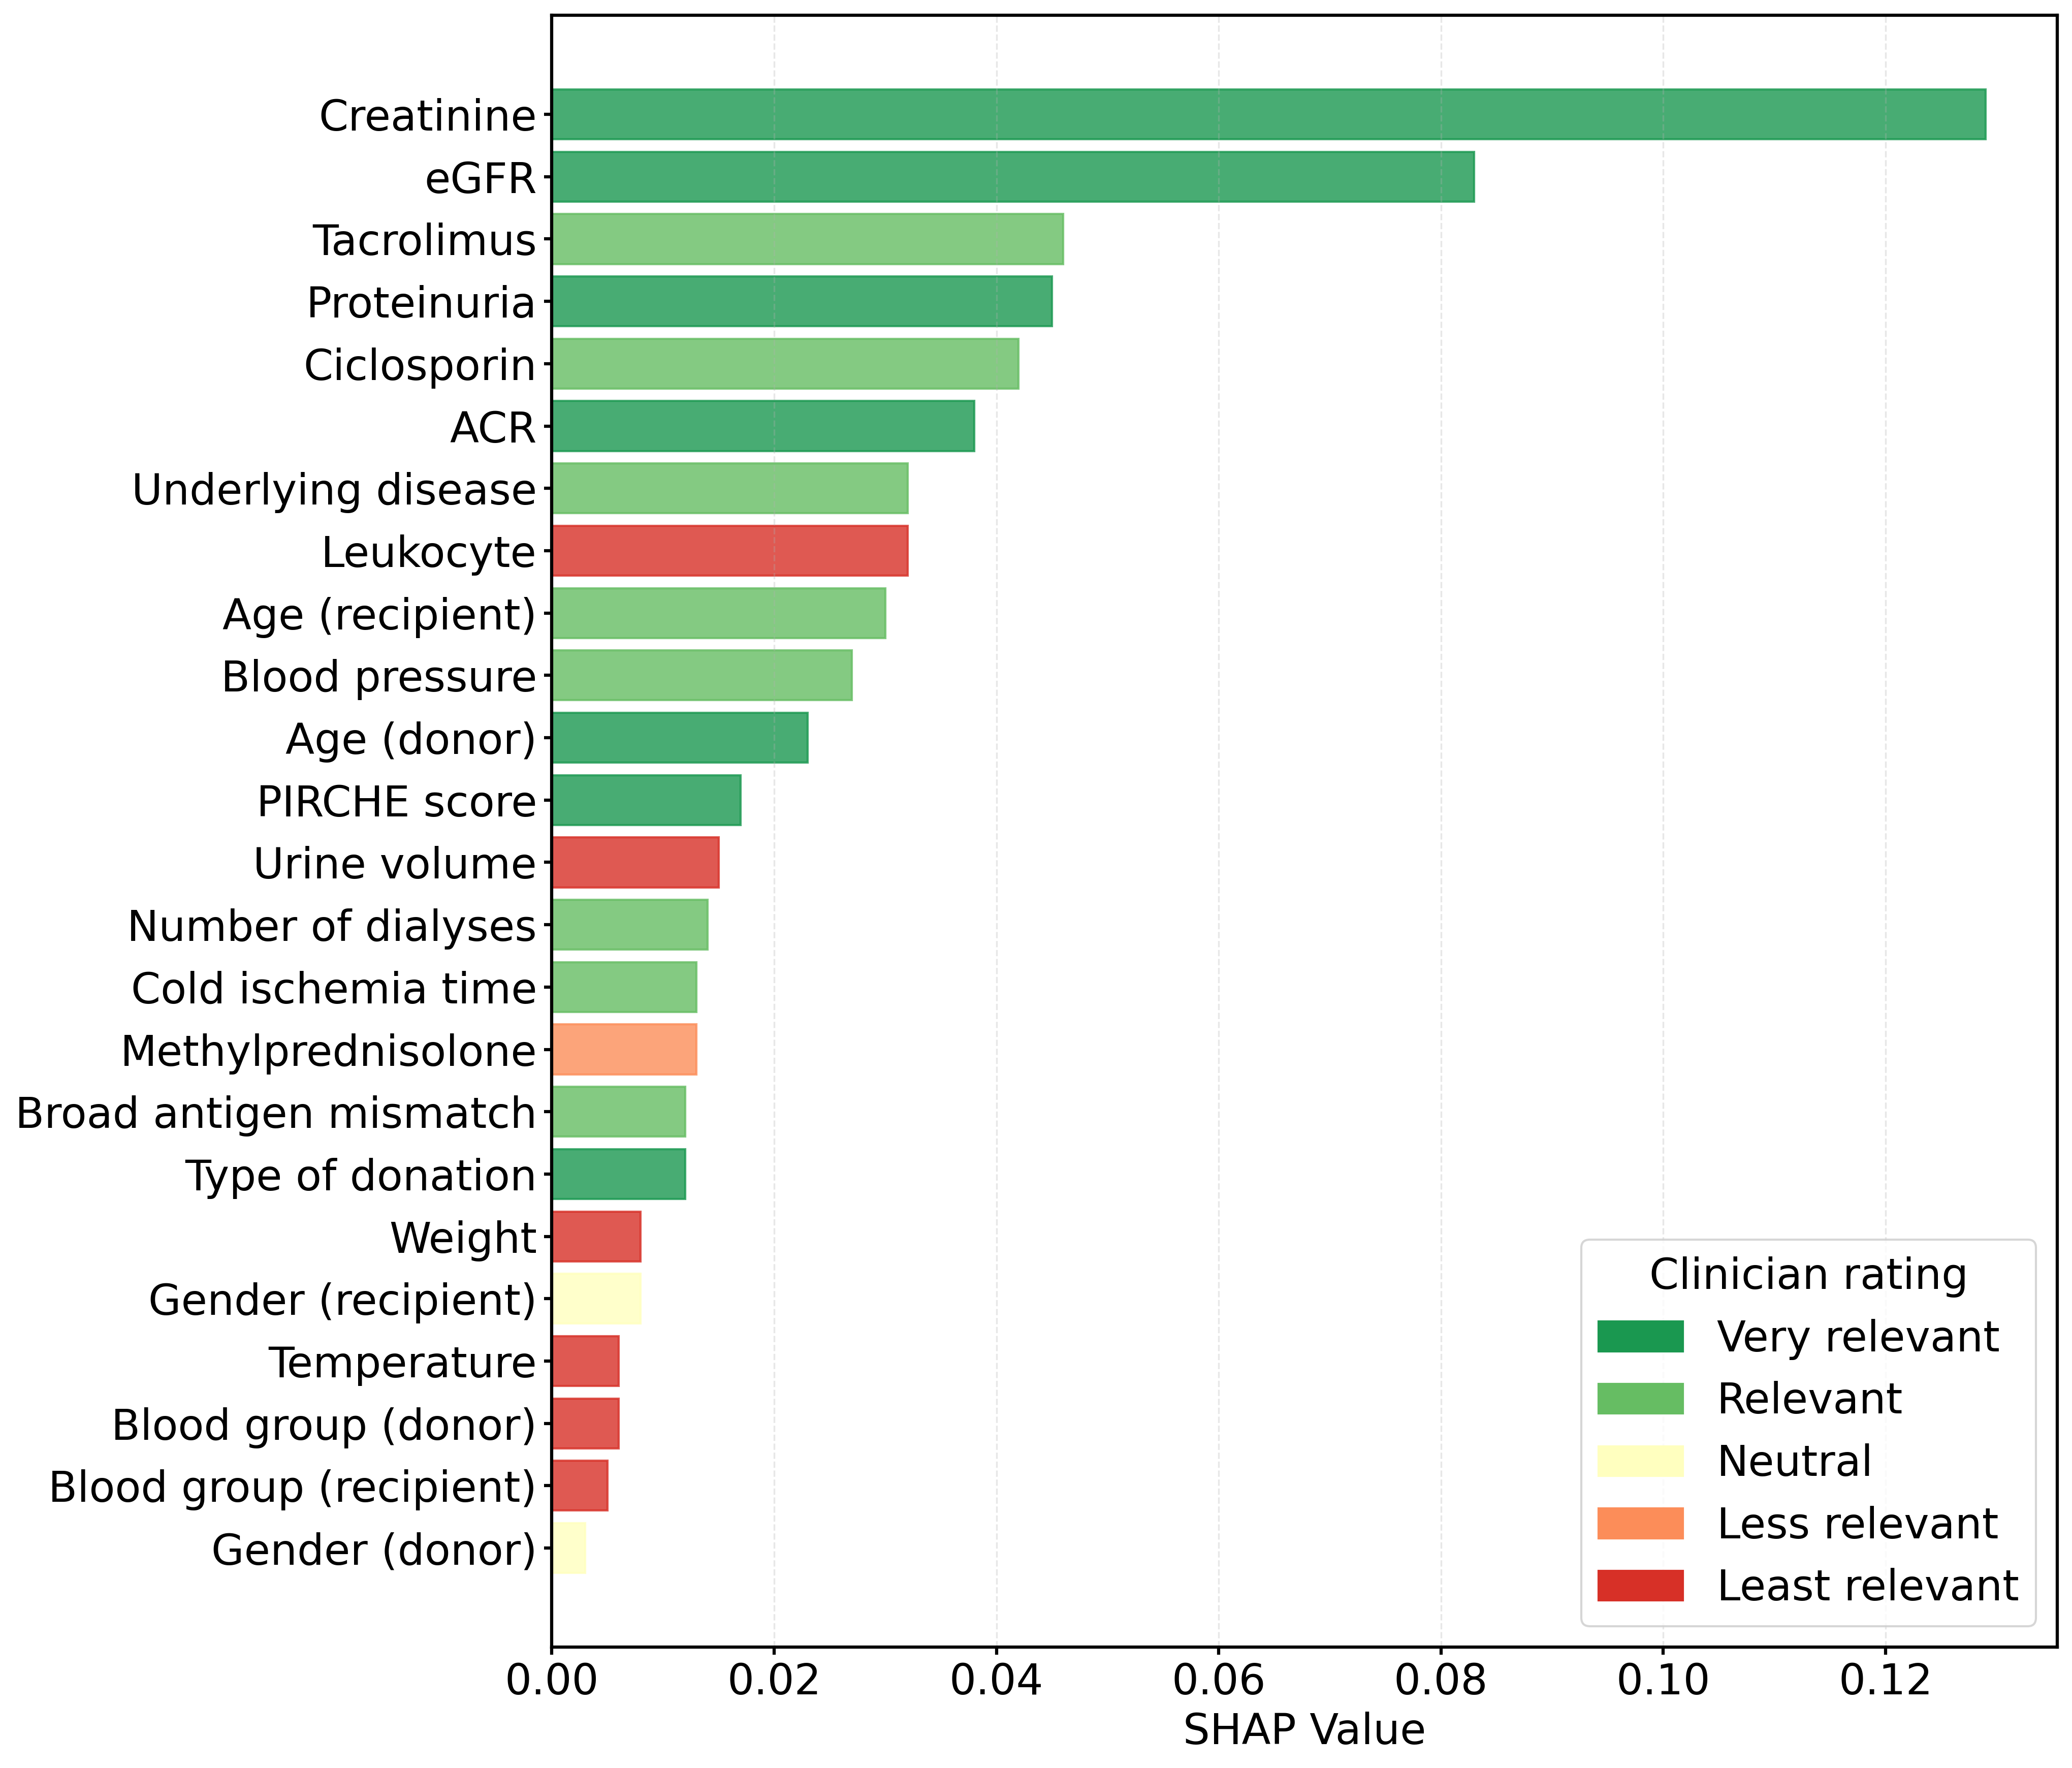


Graft Loss Feature Importance Comparison:
Feature | SHAP Value | Clinical Rating
--------------------------------------------------
Creatinine | 0.1290 | Very relevant
eGFR | 0.0830 | Very relevant
Tacrolimus | 0.0460 | Relevant
Proteinuria | 0.0450 | Very relevant
Ciclosporin | 0.0420 | Relevant
ACR | 0.0380 | Very relevant
Underlying disease | 0.0320 | Relevant
Leukocyte | 0.0320 | Least relevant
Age (recipient) | 0.0300 | Relevant
Blood pressure | 0.0270 | Relevant
Age (donor) | 0.0230 | Very relevant
PIRCHE score | 0.0170 | Very relevant
Urine volume | 0.0150 | Least relevant
Number of dialyses | 0.0140 | Relevant
Cold ischemia time | 0.0130 | Relevant
Methylprednisolone | 0.0130 | Less relevant
Broad antigen mismatch | 0.0120 | Relevant
Type of donation | 0.0120 | Very relevant
Weight | 0.0080 | Least relevant
Gender (recipient) | 0.0080 | Neutral
Temperature | 0.0060 | Least relevant
Blood group (donor) | 0.0060 | Least relevant
Blood group (recipient) | 0.0050 | Least relevant


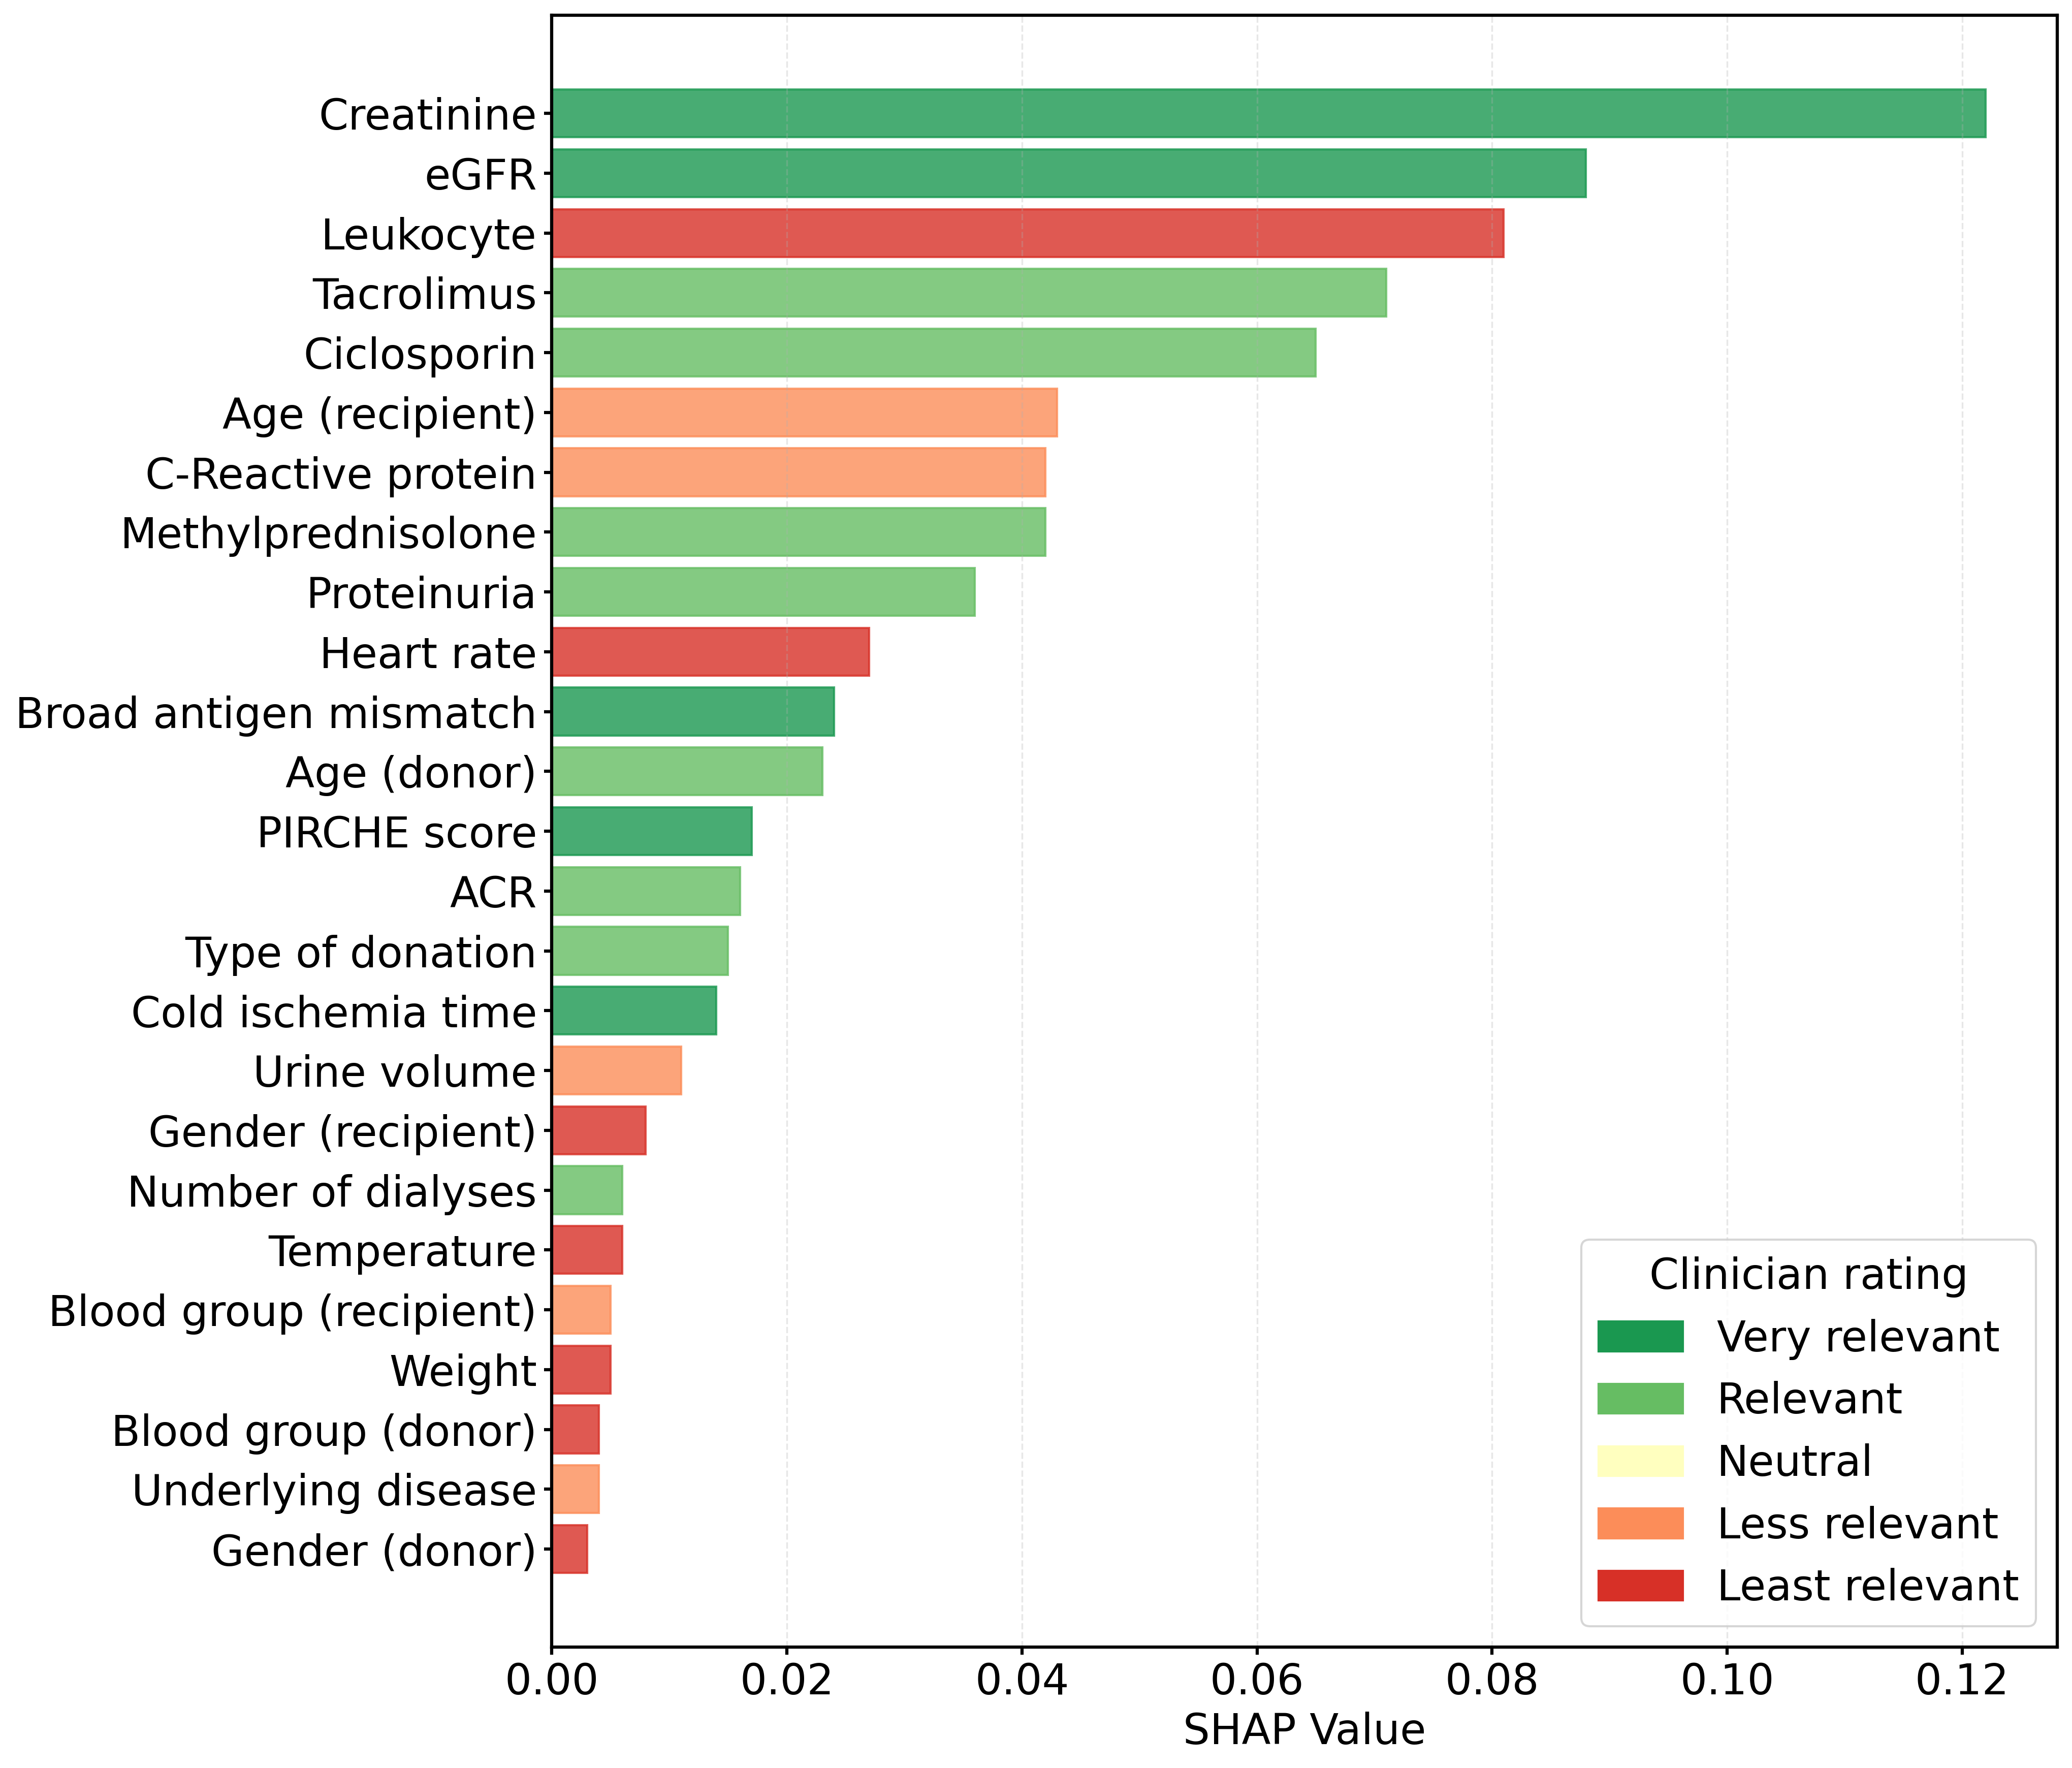


Rejection Feature Importance Comparison:
Feature | SHAP Value | Clinical Rating
--------------------------------------------------
Creatinine | 0.1220 | Very relevant
eGFR | 0.0880 | Very relevant
Leukocyte | 0.0810 | Least relevant
Tacrolimus | 0.0710 | Relevant
Ciclosporin | 0.0650 | Relevant
Age (recipient) | 0.0430 | Less relevant
C-Reactive protein | 0.0420 | Less relevant
Methylprednisolone | 0.0420 | Relevant
Proteinuria | 0.0360 | Relevant
Heart rate | 0.0270 | Least relevant
Broad antigen mismatch | 0.0240 | Very relevant
Age (donor) | 0.0230 | Relevant
PIRCHE score | 0.0170 | Very relevant
ACR | 0.0160 | Relevant
Type of donation | 0.0150 | Relevant
Cold ischemia time | 0.0140 | Very relevant
Urine volume | 0.0110 | Less relevant
Gender (recipient) | 0.0080 | Least relevant
Number of dialyses | 0.0060 | Relevant
Temperature | 0.0060 | Least relevant
Blood group (recipient) | 0.0050 | Less relevant
Weight | 0.0050 | Least relevant
Underlying disease | 0.0040 | Less relevant
B

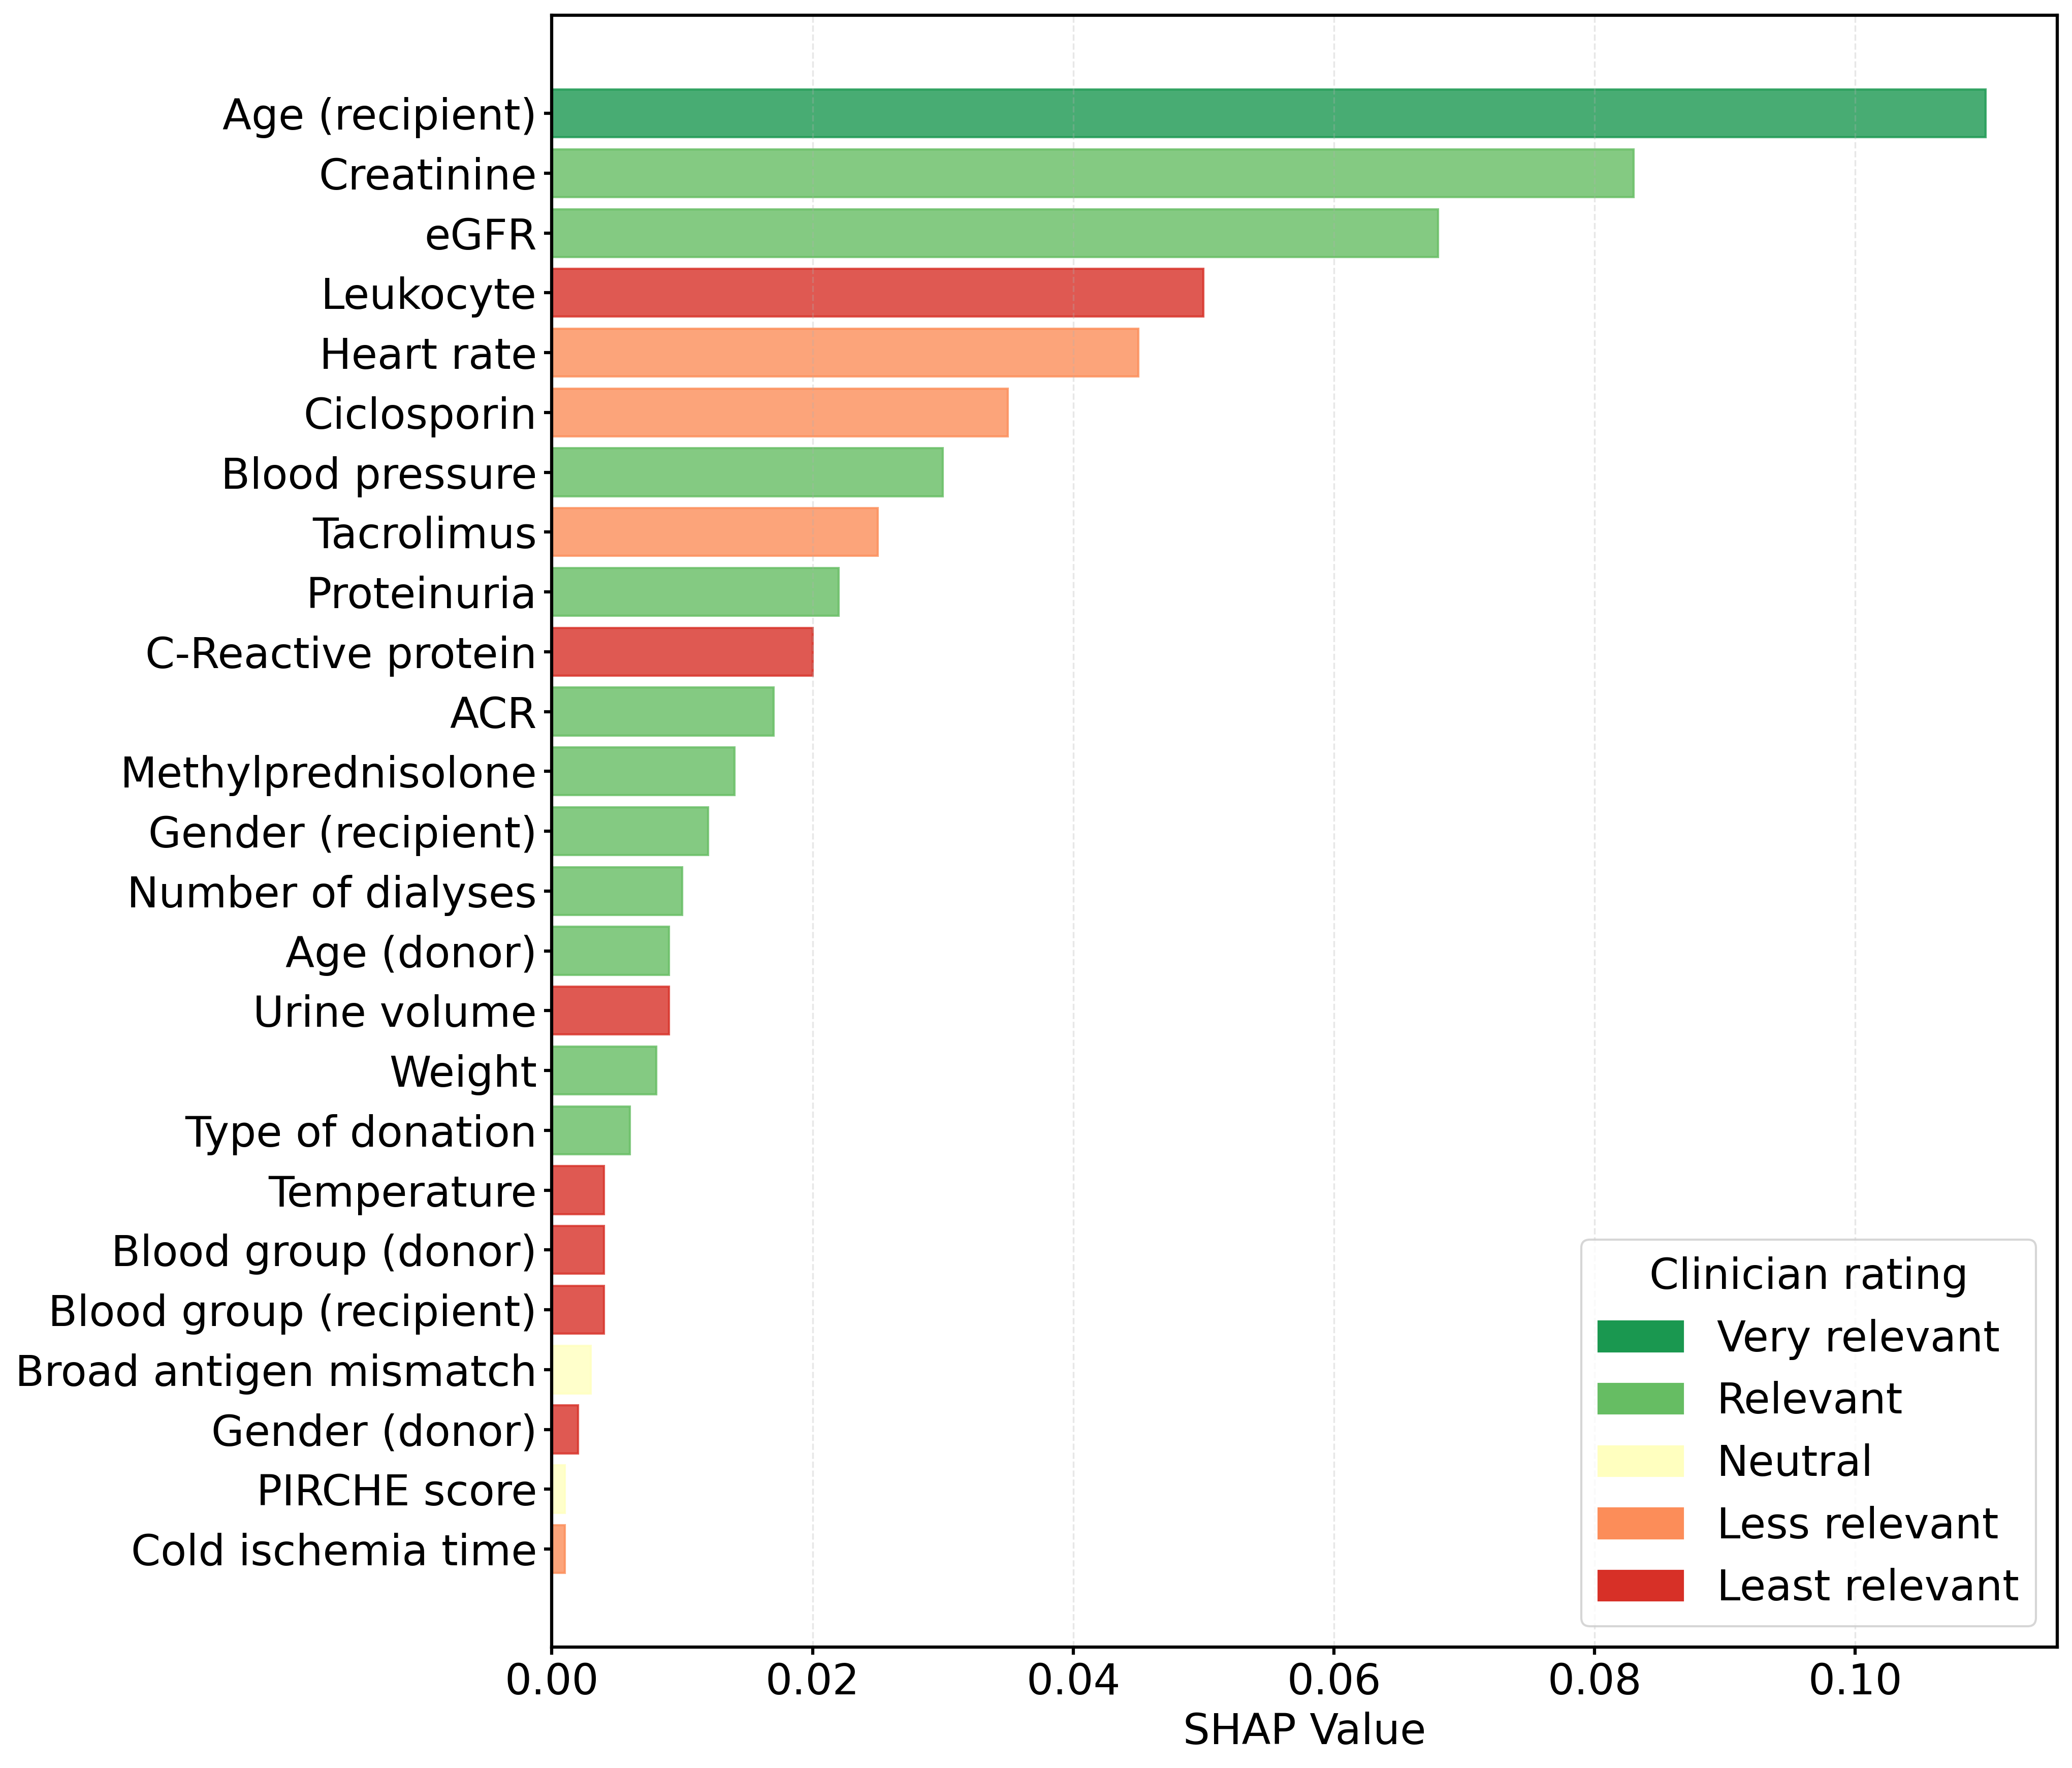


Mortality Feature Importance Comparison:
Feature | SHAP Value | Clinical Rating
--------------------------------------------------
Age (recipient) | 0.1100 | Very relevant
Creatinine | 0.0830 | Relevant
eGFR | 0.0680 | Relevant
Leukocyte | 0.0500 | Least relevant
Heart rate | 0.0450 | Less relevant
Ciclosporin | 0.0350 | Less relevant
Blood pressure | 0.0300 | Relevant
Tacrolimus | 0.0250 | Less relevant
Proteinuria | 0.0220 | Relevant
C-Reactive protein | 0.0200 | Least relevant
ACR | 0.0170 | Relevant
Methylprednisolone | 0.0140 | Relevant
Gender (recipient) | 0.0120 | Relevant
Number of dialyses | 0.0100 | Relevant
Age (donor) | 0.0090 | Relevant
Urine volume | 0.0090 | Least relevant
Weight | 0.0080 | Relevant
Type of donation | 0.0060 | Relevant
Temperature | 0.0040 | Least relevant
Blood group (donor) | 0.0040 | Least relevant
Blood group (recipient) | 0.0040 | Least relevant
Broad antigen mismatch | 0.0030 | Neutral
Gender (donor) | 0.0020 | Least relevant
PIRCHE score | 0.0010

In [134]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.colors as mcolors

# Define the translated Likert scale
likert_scale = {
    1: "Very relevant",
    2: "Relevant",
    3: "Neutral",
    4: "Less relevant",
    5: "Least relevant"
}

# Define a color map for clinical ratings
colors = ['#1a9850', '#66bd63', '#ffffbf', '#fc8d59', '#d73027']  # Green to Red
rating_cmap = mcolors.ListedColormap(colors)

# Create a mapping dictionary for feature name formatting
feature_name_mapping = {
    'Age': 'Age (recipient)',
    'gender': 'Gender (recipient)',
    'underlying_disease': 'Underlying disease',
    'blood_group': 'Blood group (recipient)',
    'cold_ischemia_time': 'Cold ischemia time',
    'gender_donor': 'Gender (donor)',
    'age_donor': 'Age (donor)',
    'donor_bloodgroup': 'Blood group (donor)',
    'type_of_donation': 'Type of donation',
    'pirche_score': 'PIRCHE score',
    'mm_broad': 'Broad antigen mismatch',
    'Heart rate': 'Heart rate',
    'hr': 'Heart rate',
    'Blood pressure': 'Blood pressure',
    'bp_sys': 'Systolic blood pressure',
    'bp_dia': 'Diastolic blood pressure',
    'weight': 'Weight',
    'Temperature': 'Temperature',
    'temperature': 'Temperature',
    'urine_volume': 'Urine volume',
    'Creatinine': 'Creatinine',
    'Leukocyte': 'Leukocyte',
    'C-reactive protein': 'C-Reactive protein',
    'crphp': 'C-Reactive protein',
    'Proteinuria': 'Proteinuria',
    'acr': 'ACR',
    'ACR': 'ACR',
    'eGFR': 'eGFR',
    'Tacrolimus': 'Tacrolimus',
    'Methylprednisolon': 'Methylprednisolone',
    'Ciclosporin': 'Ciclosporin',
    'number_dialyses': 'Number of dialyses',
    'diuresis_time': 'Diuresis time',
    'Notes embeddings': 'Notes embeddings',
    'Underlying disease': 'Underlying disease'
}

# Function to create a comparison plot for each task
def create_comparison_plot(task, shap_data, task_data):
    # Match features between datasets (handling case sensitivity)
    matched_data = []
    
    for feature in task_data[task]:
        # Find corresponding feature in SHAP data (case-insensitive)
        shap_key = None
        for k in shap_data[task].keys():
            if k.lower() == feature.lower():
                shap_key = k
                break
        
        if shap_key:
            # Use the proper English name for the feature
            proper_name = feature_name_mapping.get(feature, feature)
            
            matched_data.append({
                'feature': proper_name,
                'original_feature': feature,
                'shap_value': shap_data[task][shap_key],
                'clinical_rating': task_data[task][feature]
            })
    
    # Convert to DataFrame and sort by SHAP value
    df = pd.DataFrame(matched_data)
    df = df.sort_values('shap_value', ascending=True)  # Ascending for horizontal bars
    
    # Invert clinical ratings for correlation calculation (since 1=important, 5=unimportant)
    inverted_clinical = [6 - rating for rating in df['clinical_rating']]
    
    # Calculate Spearman correlation
    corr, p_value = stats.spearmanr(df['shap_value'], inverted_clinical)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Create horizontal bar chart of SHAP values
    bars = ax.barh(df['feature'], df['shap_value'], align='center', alpha=0.8)
    
    # Color the bars according to clinical rating
    for i, (bar, rating) in enumerate(zip(bars, df['clinical_rating'])):
        bar.set_color(colors[rating-1])
        
        # Add clinical rating text next to each bar
        #ax.text(bar.get_width() + 0.001, i, f"  {likert_scale[rating]}", va='center', fontsize=10)
    
    # Set axis labels and title
    ax.set_xlabel('SHAP Value')
    #ax.set_title(f"{task}: Model vs Clinical Feature Importance\nSpearman ρ = {corr:.3f} (p = {p_value:.3f})", pad=20)
    
    # Adjust tick label font size
    ax.tick_params(axis='y')
    
    # Add legend for clinical ratings
    legend_elements = [plt.Rectangle((0, 0), 1, 1, color=colors[i-1], label=likert_scale[i]) for i in range(1, 6)]
    ax.legend(handles=legend_elements, loc='lower right', title="Clinician rating")
    
    # Add grid to make it easier to read
    ax.grid(True, linestyle='--', alpha=0.3, axis='x')
    
    plt.tight_layout()
    return fig, corr, p_value, df

# Process each task
tasks = ["Graft Loss", "Rejection", "Mortality"]
results = {}

for task in tasks:
    fig, corr, p_value, data = create_comparison_plot(task, shap_data, task_data)
    plt.savefig(f"../plots/{task.replace(' ', '_')}_feature_importance.jpg", dpi=300, bbox_inches="tight")
    plt.show()
    
    # Print table of results for this task
    print(f"\n{task} Feature Importance Comparison:")
    print("Feature | SHAP Value | Clinical Rating")
    print("-" * 50)
    for _, row in data.sort_values('shap_value', ascending=False).iterrows():
        print(f"{row['feature']} | {row['shap_value']:.4f} | {likert_scale[row['clinical_rating']]}")
    
    results[task] = {"correlation": corr, "p_value": p_value}

# Print overall correlation results
print("\nSpearman's Rank Correlation Results:")
for task, res in results.items():
    print(f"{task}: ρ = {res['correlation']:.3f} (p = {res['p_value']:.3f})")